In [65]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
#Load the data
df = pd.read_csv('AirPassengers.csv')
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [67]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [68]:
df.shape

(144, 2)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [70]:
#Month is in object format we need to convert to datetime format
df['Month'] = pd.to_datetime(df['Month'])

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [72]:
#Check null values - No need to drop null values, we have to do forwardfill, backwardfill, rolling mean
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [73]:
df.duplicated().sum()

0

In [74]:
df.index

RangeIndex(start=0, stop=144, step=1)

In [75]:
#Datetime column as index column
df.index = df['Month']

In [76]:
df

,Month,#Passengers
Month,,
1949-01-01,1949-01-01,112
1949-02-01,1949-02-01,118
1949-03-01,1949-03-01,132
1949-04-01,1949-04-01,129
1949-05-01,1949-05-01,121
...,...,...
1960-08-01,1960-08-01,606
1960-09-01,1960-09-01,508
1960-10-01,1960-10-01,461


In [77]:
#Delete extra month column
del df['Month']

In [78]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


<Axes: xlabel='Month'>

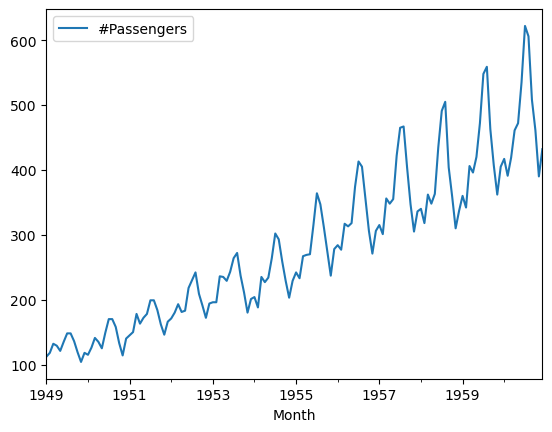

In [79]:
df.plot()

In [80]:
#Checking if data is stationary or not we use ADF Test(Augmented-Dicky-Fuller Test)
#if p_value<=0.05 #Alternate hypothesis - Data is stationary
#if p_value>0.05 #Null hypothesis - Data is not stationary

In [81]:
from statsmodels.tsa.stattools import adfuller

In [82]:
result = adfuller(df['#Passengers'])
result

(0.8153688792060482,
 0.991880243437641,
 13,
 130,
 {'1%': -3.4816817173418295,
  '5%': -2.8840418343195267,
  '10%': -2.578770059171598},
 996.692930839019)

In [83]:
p_value = result[1]
p_value

0.991880243437641

In [84]:
if p_value <= 0.05:
    print('Null hypothesis is reject our data is stationary')
else:
    print('Null hypothesis is accpeted our data is not stationary')

Null hypothesis is accpeted our data is not stationary


In [85]:
#Alternate way to check stationarity
from pandas.core.window.rolling import Window
rolling_mean = df.rolling(window=12).mean()
rolling_std = df.rolling(window=12).std()

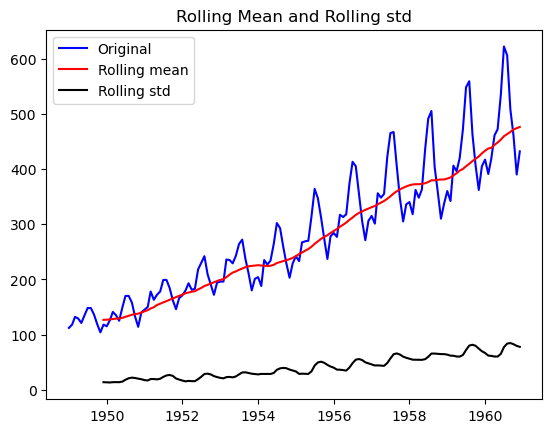

In [86]:
plt.plot(df, color='blue', label ='Original')
plt.plot(rolling_mean, color='red', label='Rolling mean')
plt.plot(rolling_std, color ='black', label='Rolling std')
plt.legend(loc='best')
plt.title('Rolling Mean and Rolling std')
plt.show()

In [87]:
#Seasonal decompose to check presense of components
from statsmodels.tsa.seasonal import seasonal_decompose

In [88]:
decompose = seasonal_decompose(df['#Passengers'])

Figure(640x480)


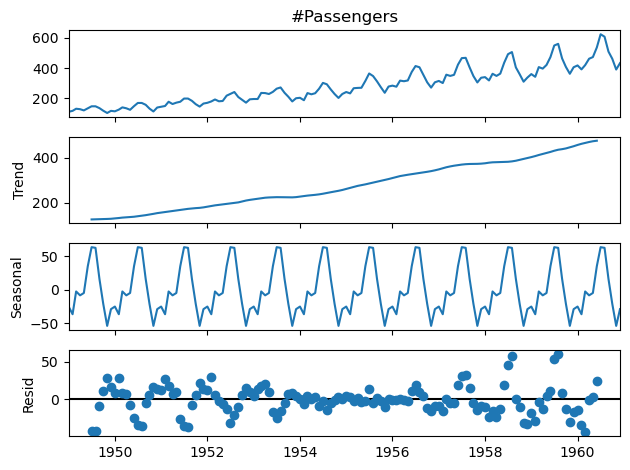

In [89]:
print(decompose.plot())

#Insights
1) Data has trends
2) Data has seasonality
3) Data has residuals also

In [90]:
#Log Transformation
log_df = np.log(df)
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [91]:
rolling_mean=log_df.rolling(window=12).mean()
rolling_std=log_df.rolling(window=12).std()

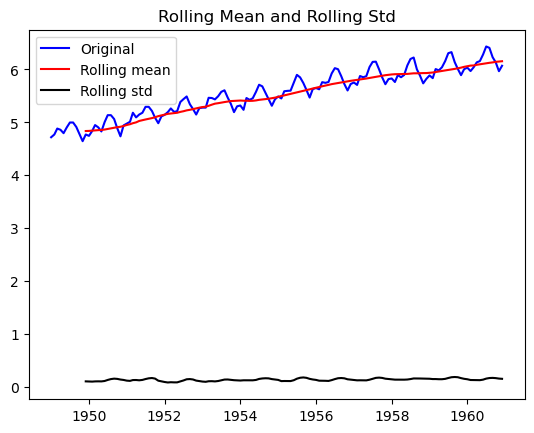

In [92]:
plt.plot(log_df,color='blue',label='Original')
plt.plot(rolling_mean,color='red',label='Rolling mean')
plt.plot(rolling_std,color='black',label='Rolling std')
plt.legend(loc='best')
plt.title('Rolling Mean and Rolling Std')
plt.show()

In [93]:
#Data is not stationary now we need to apply differencing


In [94]:
#perform differencing 1 time
diff_data=log_df.diff()
diff_data

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


In [95]:
diff_data.dropna(inplace=True)

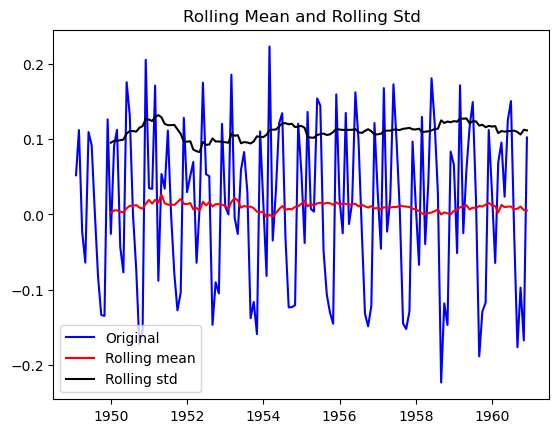

In [96]:
rolling_mean=diff_data.rolling(window=12).mean()
rolling_std=diff_data.rolling(window=12).std()

plt.plot(diff_data,color='blue',label='Original')
plt.plot(rolling_mean,color='red',label='Rolling mean')
plt.plot(rolling_std,color='black',label='Rolling std')
plt.legend(loc='best')
plt.title('Rolling Mean and Rolling Std')
plt.show()

In [97]:
result=adfuller(diff_data['#Passengers'])
p_value=result[1]
p_value

0.07112054815085875

In [98]:
# lets consider the above data as stationary as we dont want to loose more data and we got the marginal p

Model Building

In [99]:
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [100]:
#split the data into train and test - total months - 144 months
train=log_df.iloc[:120,:]  #120 months(10 Years) as training(83%)
test=log_df.iloc[120:,:]   #24 months(2 years) as testing(17%)

ARIMA(Auto Regressive Integrated Moving Average)

In [103]:
from statsmodels.tsa.arima.model import ARIMA

In [104]:
model = ARIMA(train, order=(1,1,2))

c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [105]:
model = model.fit()

In [106]:
log_df['Arima Predictions'] = model.predict(start = len(train), end = len(train) + len(test)-1)

In [107]:
log_df

,#Passengers,Arima Predictions
Month,,
1949-01-01,4.718499,NaN
1949-02-01,4.770685,NaN
1949-03-01,4.882802,NaN
1949-04-01,4.859812,NaN
1949-05-01,4.795791,NaN
...,...,...
1960-08-01,6.406880,5.912388
1960-09-01,6.230481,5.912388
1960-10-01,6.133398,5.912388


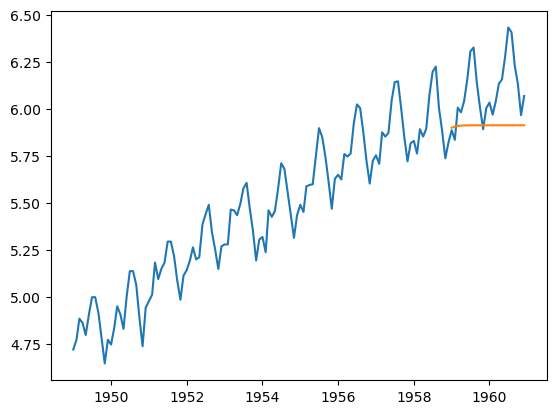

In [108]:
plt.plot(log_df)

In [110]:
#our prediction is not coming good as we have not taken the optimal value of p and q

In [111]:
#Itertools - to find optimal value of p, d, q
import itertools

In [112]:
p = range(1,8)
d = range(1,2)
q = range(1, 8)
pdq_combination = list(itertools.product(p,d,q))
pdq_combination

[(1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (1, 1, 7),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (2, 1, 7),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (3, 1, 7),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (4, 1, 7),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5, 1, 6),
 (5, 1, 7),
 (6, 1, 1),
 (6, 1, 2),
 (6, 1, 3),
 (6, 1, 4),
 (6, 1, 5),
 (6, 1, 6),
 (6, 1, 7),
 (7, 1, 1),
 (7, 1, 2),
 (7, 1, 3),
 (7, 1, 4),
 (7, 1, 5),
 (7, 1, 6),
 (7, 1, 7)]

In [113]:
len(pdq_combination)

49

In [114]:
from sklearn.metrics import mean_squared_error

In [115]:
rmse=[]
order1=[]
for pdq in pdq_combination:
  model=ARIMA(train,order=pdq)
  model_fit=model.fit()
  pred=model_fit.predict(start=len(train),end=len(train)+len(test)-1)
  error=np.sqrt(mean_squared_error(test,pred))
  order1.append(pdq)
  rmse.append(error)

c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

In [116]:
results=pd.DataFrame(index=order1, data=rmse,columns=['RMSE'])

In [117]:
results.sort_values(by='RMSE',ascending=True)

,RMSE
"(5, 1, 4)",0.147948
"(7, 1, 7)",0.156252
"(6, 1, 4)",0.159827
"(7, 1, 5)",0.170810
"(7, 1, 4)",0.176992
"(6, 1, 5)",0.182067
"(5, 1, 5)",0.184721
"(7, 1, 2)",0.188385
"(4, 1, 4)",0.194104
"(4, 1, 7)",0.195225


In [118]:
# From the above list we found the best order is (5,1,4)

In [119]:
from statsmodels.tsa.arima.model import ARIMA

In [120]:
model=ARIMA(train,order=(5,1,4))
model1=model.fit()
log_df['Arima Predictions']=model1.predict(start=len(train),end=len(train)+len(test)-1)

c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [121]:
log_df

,#Passengers,Arima Predictions
Month,,
1949-01-01,4.718499,NaN
1949-02-01,4.770685,NaN
1949-03-01,4.882802,NaN
1949-04-01,4.859812,NaN
1949-05-01,4.795791,NaN
...,...,...
1960-08-01,6.406880,6.091665
1960-09-01,6.230481,6.031928
1960-10-01,6.133398,5.939303


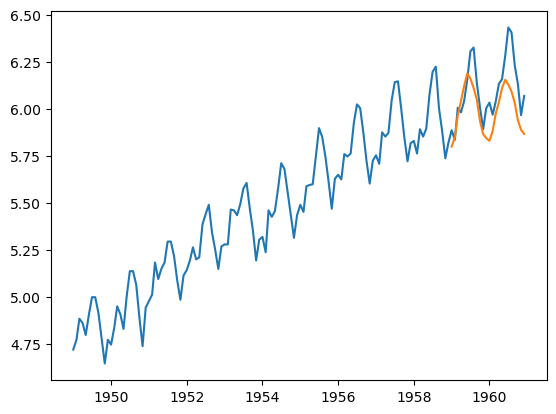

In [122]:
plt.plot(log_df)

In [123]:
#Implementation of Sarima
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [124]:
s_model=SARIMAX(train,order=(5,1,4),seasonal_order=(5,1,4,12))  #seasonality=12

c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [125]:
s_model=s_model.fit()
log_df['Sarima_Prediction']=s_model.predict(start=len(train),end=len(train)+len(test)-1)

c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\sahaj\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

In [126]:
log_df

,#Passengers,Arima Predictions,Sarima_Prediction
Month,,,
1949-01-01,4.718499,NaN,NaN
1949-02-01,4.770685,NaN,NaN
1949-03-01,4.882802,NaN,NaN
1949-04-01,4.859812,NaN,NaN
1949-05-01,4.795791,NaN,NaN
...,...,...,...
1960-08-01,6.406880,6.091665,6.343752
1960-09-01,6.230481,6.031928,6.172468
1960-10-01,6.133398,5.939303,6.032108


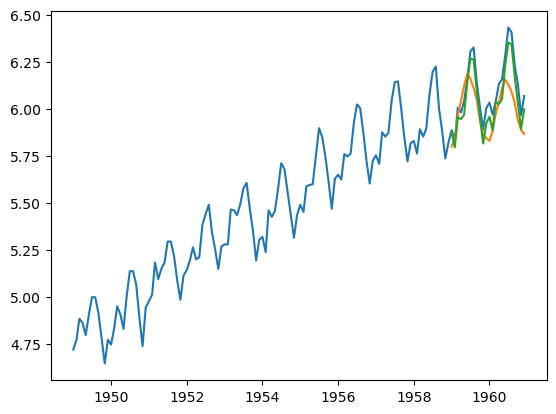

In [127]:
plt.plot(log_df)

In [128]:
#forecast - future prediction
future=s_model.forecast(steps=60)

In [129]:
future

1959-01-01    5.874254
1959-02-01    5.795518
1959-03-01    5.955547
1959-04-01    5.944951
1959-05-01    5.968235
1959-06-01    6.145310
1959-07-01    6.267281
1959-08-01    6.262824
1959-09-01    6.089936
1959-10-01    5.957193
1959-11-01    5.815224
1959-12-01    5.921724
1960-01-01    5.958019
1960-02-01    5.885250
1960-03-01    6.037134
1960-04-01    6.025761
1960-05-01    6.051387
1960-06-01    6.232756
1960-07-01    6.353189
1960-08-01    6.343752
1960-09-01    6.172468
1960-10-01    6.032108
1960-11-01    5.893891
1960-12-01    5.997722
1961-01-01    6.034400
1961-02-01    5.964232
1961-03-01    6.112305
1961-04-01    6.098345
1961-05-01    6.122985
1961-06-01    6.315432
1961-07-01    6.434094
1961-08-01    6.428701
1961-09-01    6.255815
1961-10-01    6.110602
1961-11-01    5.972424
1961-12-01    6.073136
1962-01-01    6.104786
1962-02-01    6.036255
1962-03-01    6.174435
1962-04-01    6.153924
1962-05-01    6.182067
1962-06-01    6.377878
1962-07-01    6.496958
1962-08-01 

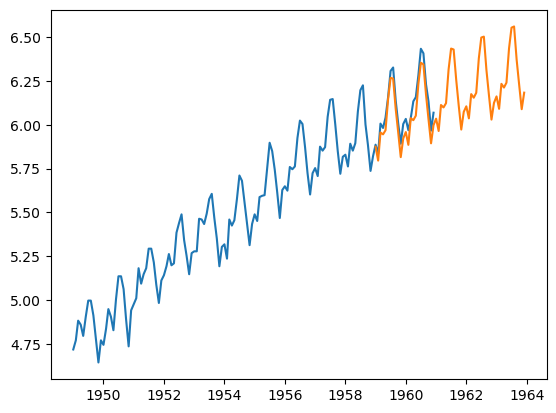

In [138]:
plt.plot(log_df['#Passengers'])
plt.plot(future)
plt.show()

In [131]:
round(np.exp(future))   #Actual values of Passengers

1959-01-01    356.0
1959-02-01    329.0
1959-03-01    386.0
1959-04-01    382.0
1959-05-01    391.0
1959-06-01    467.0
1959-07-01    527.0
1959-08-01    525.0
1959-09-01    441.0
1959-10-01    387.0
1959-11-01    335.0
1959-12-01    373.0
1960-01-01    387.0
1960-02-01    360.0
1960-03-01    419.0
1960-04-01    414.0
1960-05-01    425.0
1960-06-01    509.0
1960-07-01    574.0
1960-08-01    569.0
1960-09-01    479.0
1960-10-01    417.0
1960-11-01    363.0
1960-12-01    403.0
1961-01-01    418.0
1961-02-01    389.0
1961-03-01    451.0
1961-04-01    445.0
1961-05-01    456.0
1961-06-01    553.0
1961-07-01    623.0
1961-08-01    619.0
1961-09-01    521.0
1961-10-01    451.0
1961-11-01    392.0
1961-12-01    434.0
1962-01-01    448.0
1962-02-01    418.0
1962-03-01    480.0
1962-04-01    471.0
1962-05-01    484.0
1962-06-01    589.0
1962-07-01    663.0
1962-08-01    667.0
1962-09-01    551.0
1962-10-01    479.0
1962-11-01    415.0
1962-12-01    457.0
1963-01-01    474.0
1963-02-01    442.0


# Business Decisions :

For Airlines:

Increase flights during peak months.

Reduce the operational costs during off peak months.

Optimize crew and aircraft utlization.

For Operations:

Better fuel, staff and maintainance planning.